In [1]:
import numpy as np
import scipy
import seaborn as sns
from scipy.stats import norm
from collections import defaultdict
from matplotlib import pyplot as plt
from tqdm import tqdm
from pathlib import Path
import torch
from torch.utils.data import DataLoader

import sys
sys.path.append('../../src')
root = Path('../../src')
from utils.yaml import parse_yaml
from utils.utils import load_checkpoint
from metrics.testing import infonce
device = torch.device('cuda:0')

In [2]:
DATASET = 'riab'
CRITICS = ['nds'] #['nce', 'nds']

# hyperparams
DATASIZE = 17000
TESTSIZES = [500, 750, 1000, 1250, 1500] # [200, 300, 400, 500,] # [500, 750, 1000, 1250, 1500]
NTEST = 500
NPERM = 200
NBOOT = 1000
ALPHA = 0.05

power = dict()
power['asymp'] = defaultdict(dict)
power['empir'] = defaultdict(dict)
power['perm'] = defaultdict(dict)

## Load Model and Dataset

In [3]:
# dataset
dataset_cfg = dict()
dataset_cfg['riab'] = root/"config/dataset/riab/riab.present.5000.yml"
dataset_cfg['sinusoid'] = root/"config/dataset/sinusoid/sinusoid-generator.yml"
dataset_cfg['hdgm4'] = root/"config/dataset/hdgm/hdgm4-generator.yml"

# model architectures
model_cfg = defaultdict(dict)
model_cfg['riab']['nce'] = root/"config/model/infonce/id-id@mlp10x32x64x32x1.yml"
model_cfg['riab']['nds'] = root/"config/model/mi/id-id@mlp10x32x64x32x1.yml"
model_cfg['riab']['hsic'] = root/"config/model/hsic/mlp8x32x64x32-mlp2x4x8x4.yml"
model_cfg['sinusoid']['nce'] = root/"config/model/infonce/id-id@mlp2x8x12x8x1.yml"
model_cfg['sinusoid']['nds'] = root/"config/model/mi/id-id@mlp2x8x12x8x1.yml"
model_cfg['sinusoid']['hsic'] = root/"config/model/hsic/mlp1x8x12x8-squared.yml"
model_cfg['hdgm4']['nce'] = root/"config/model/infonce/id-id@mlp4x8x12x8x1.yml"
model_cfg['hdgm4']['nds'] = root/"config/model/mi/id-id@mlp4x8x12x8x1.yml"
model_cfg['hdgm4']['hsic'] = root/"config/model/hsic/mlp2x4x6x4-squared.yml"

# pretrained paths
pretrain_pth = defaultdict(dict)
pretrain_pth['riab']['nce'] = "pretrained/nce-riab.pt"
pretrain_pth['riab']['nds'] = "pretrained/nds-riab.pt"
pretrain_pth['sinusoid']['nce'] = "pretrained/nce-sinusoid.pt"
pretrain_pth['sinusoid']['nds'] = "pretrained/nds-sinusoid.pt"
pretrain_pth['sinusoid']['hsic'] = None
pretrain_pth['hdgm4']['nce'] = "pretrained/nce-hdgm4.pt"
pretrain_pth['hdgm4']['nds'] = "pretrained/nds-hdgm4-2.pt"

In [4]:
models = dict()
for critic in CRITICS:
    models[critic] = parse_yaml(model_cfg[DATASET][critic]).build()
    load_checkpoint(pretrain_pth[DATASET][critic], models[critic], device=device)
    models[critic].double()
    models[critic].to(device)
    models[critic].eval()

dataconfig = parse_yaml(dataset_cfg[DATASET])['test']
if 'root' in dataconfig:
    dataconfig['root'] = root/dataconfig['root']
dataset = dataconfig.build()

def stream(dataloader):
    while True:
        yield from dataloader
loader_args = {'shuffle': True, 'drop_last': True} if DATASET == 'riab' else {}

## Compute Gram Matrices

In [5]:
dataloader = DataLoader(dataset, batch_size=DATASIZE, **loader_args)
data = next(iter(dataloader))
del dataloader
X, Y = data
X = X.to(device)
Y = Y.to(device)

grams = dict()
with torch.no_grad():
    for critic in CRITICS:
        grams[critic] = infonce.gram(models[critic], X, Y).cpu().numpy()

## Asymptotic Formula

In [20]:
dataloader = DataLoader(dataset, batch_size=DATASIZE, **loader_args)
dataiter = iter(stream(dataloader))
asymp_stats = dict()

with torch.no_grad():
    for critic in CRITICS:

        # sample from T1
        X, Y = next(dataiter)
        X = X.to(device)
        Y = Y.to(device)
        fxy = models[critic](X, Y).cpu().numpy()
        T1 = np.mean(fxy)
        T1_std = np.std(fxy)

        # sample from T0
        X, _ = next(dataiter)
        _, Y = next(dataiter)
        X = X.to(device)
        Y = Y.to(device)
        fxy = models[critic](X, Y).cpu().numpy()
        T0 = np.mean(fxy)
        T0_std = np.std(fxy)

        asymp_stats[critic] = {
            'T1': T1,
            'T1_std': T1_std,
            'T0': T0,
            'T0_std': T0_std,
        }
print(f"{asymp_stats=}")

for critic in CRITICS:
    stats = asymp_stats[critic]
    T1 = stats['T1']
    T1_std = stats['T1_std']
    T0 = stats['T0']
    T0_std = stats['T0_std']
    snr = (T1 - T0) / T1_std
    sdr = T0_std / T1_std
    print(f"[{critic}] {snr=}\t{sdr=}")

    for m in tqdm(TESTSIZES):
        power['asymp'][critic][f'm={m}'] = norm.cdf(np.sqrt(m) * snr + norm.ppf(ALPHA) * sdr)

asymp_stats={'nds': {'T1': -0.0012838249647207259, 'T1_std': 0.000759985461999044, 'T0': -0.0013156244490357012, 'T0_std': 0.0007906526467295663}}
[nds] snr=0.04184222712804391	sdr=1.0403523307536122


100%|██████████| 5/5 [00:00<00:00, 6758.47it/s]


In [ ]:
# dataset-level statistics
asymp_stats = dict()
for key, blk in grams.items():
    m = blk.shape[0]
    perm0 = np.arange(m)
    perm1 = np.random.permutation(m)
    T1 = blk[perm0, perm0].mean()
    T1_std = blk[perm0, perm0].std()
    T0 = blk[perm0, perm1].mean()
    T0_std = blk[perm0, perm1].std()
    asymp_stats[key] = {
        'T1': T1,
        'T1_std': T1_std,
        'T0': T0,
        'T0_std': T0_std,
    }
print(asymp_stats)

def asymp_power(m: int, alpha: float, critic: str):
    stats = asymp_stats[critic]
    T1 = stats['T1']
    T1_std = stats['T1_std']
    T0 = stats['T0']
    T0_std = stats['T0_std']
    snr = (T1 - T0) / T1_std
    return norm.cdf(np.sqrt(m) * snr + (T0_std / T1_std) * norm.ppf(alpha))

for critic in CRITICS:
    for m in tqdm(TESTSIZES):
        power['asymp'][critic][f'm={m}'] = asymp_power(m, ALPHA, critic)

## Permutation Test

In [7]:
def perm_power(m: int, n_test: int, n_perm: int, alpha: float, critic: str):
    gram: np.ndarray = grams[critic]
    n = gram.shape[0]

    T1s = np.full(n_test, np.nan)
    threshes = np.full(n_test, np.nan)
    for i in range(n_test):

        perm0 = np.arange(m)
        which = np.random.choice(n, m, replace=False)
        blk = gram[np.ix_(which, which)]

        # compute test statistic T1
        T1s[i] = np.diagonal(blk).mean()

        # compute thresh based on permutations
        perms = np.array([np.random.permutation(m) for _ in range(n_perm)])     # (nperm, m)
        T0s = blk[perm0, perms].mean(-1)
        threshes[i] = np.quantile(T0s, 1-alpha, method='inverted_cdf')

    return (T1s > threshes).mean()


for critic in CRITICS:
    for m in tqdm(TESTSIZES):
        power['perm'][critic][f'm={m}'] = perm_power(m, NTEST, NPERM, ALPHA, critic)

100%|██████████| 5/5 [00:42<00:00,  8.50s/it]


## Empirical Threshold

In [8]:
@torch.no_grad
def empirical_power(m: int, n_test: int, n_boot: int, alpha: float, critic: str):
    # m: sample size
    # n_test: number of tests used to estimate power
    # n_boot: number of bootstrap samples from T(X,Y) used to estimate threshold
    testloader = stream(DataLoader(dataset, batch_size=2*m, **loader_args))

    # compute threshold
    T0s = np.full(n_boot, np.nan)
    for i, data in zip(range(n_boot), testloader):
        X, Y = data
        X = X.to(device)
        Y = Y.to(device)
        fxy = models[critic](X[:m], Y[m:]).cpu().numpy()
        T0s[i] = np.mean(fxy)
    thresh = np.quantile(T0s, q=1-alpha, method='inverted_cdf')
    del testloader


    testloader = stream(DataLoader(dataset, batch_size=m, **loader_args))
    T1s = np.full(n_test, np.nan)
    for i, data in zip(range(n_test), testloader):
        X, Y = data
        X = X.to(device)
        Y = Y.to(device)
        fxy = models[critic](X, Y).cpu().numpy()
        T1s[i] = np.mean(fxy)
    power =  (T1s > thresh).mean()
    return power

    gram = grams[critic]
    n = gram.shape[0]
    T1s = np.full(n_test, np.nan)
    for i in range(n_test):
        which = np.random.choice(n, m, replace=False)
        blk = gram[np.ix_(which, which)]
        T1s[i] = np.diag(blk).mean()
    power =  (T1s > thresh).mean()
    return power


for critic in CRITICS:
    for m in tqdm(TESTSIZES):
        power['empir'][critic][f'm={m}'] = empirical_power(m, NTEST, NBOOT, ALPHA, critic)

100%|██████████| 5/5 [01:02<00:00, 12.52s/it]


## Plots

In [ ]:
fig, axes = plt.subplots(1, 2, squeeze=False, layout='constrained', figsize=(10, 5),)

for row in axes:
    for ax, critic in zip(row, CRITICS):

        power_asymp = list(power['asymp'][critic].values())
        power_empir = list(power['empir'][critic].values())
        power_perm = list(power['perm'][critic].values())

        ax.plot(TESTSIZES, power_asymp, linewidth=2, label='asymp')
        ax.plot(TESTSIZES, power_empir, linewidth=2, label='empirical')
        ax.plot(TESTSIZES, power_perm, linewidth=2, label='perm')

        ax.set_title(f'{critic} power' )
        # ax.annotate(f'correlation: {corr:.0%}', xy=(0.99, 0.02), xycoords='axes fraction', ha='right')

        ax.set_xlabel(r'test size $m$')
        ax.set_ylabel(r'power')
        ax.legend(loc='lower right')

# plt.savefig('hdgm4-asymptotic-power (4).pdf', bbox_inches='tight')

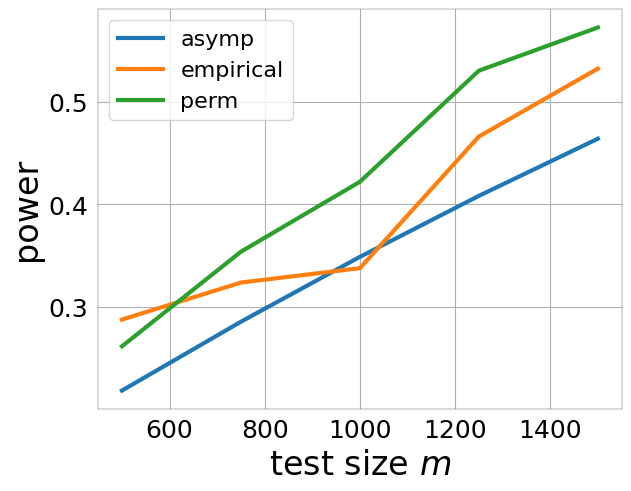

In [21]:
CRITIC = CRITICS[0]

fig, ax = plt.subplots(layout='constrained', figsize=(6.2, 4.8),) #(5, 5),)

power_asymp = list(power['asymp'][CRITIC].values())
power_empir = list(power['empir'][CRITIC].values())
power_perm = list(power['perm'][CRITIC].values())

ax.plot(TESTSIZES, power_asymp, linewidth=3, label='asymp')
ax.plot(TESTSIZES, power_empir, linewidth=3, label='empirical')
ax.plot(TESTSIZES, power_perm, linewidth=3, label='perm')

# ax.set_title(f'{DATASET}: {CRITIC}' )
# ax.annotate(f'correlation: {corr:.0%}', xy=(0.99, 0.02), xycoords='axes fraction', ha='right')

ax.set_xlabel(r'test size $m$', fontsize=24)
ax.set_ylabel(r'power', fontsize=24)
ax.legend(fontsize=16) #, loc='lower right')
# ax.set_ylim([0., 1.])

plt.grid()
plt.rcParams['axes.linewidth'] = 0.2
plt.tick_params(left=False, labelsize=18)
plt.tick_params(bottom=False, labelsize=18)


# plt.savefig(f'{CRITIC}-asymptotics-{DATASET}-1.pdf', bbox_inches='tight')

## TODO

- try fresh samples for std estimation as well
- try larger sample size (m=50000?)
- try another training run for nds